In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

C:\Users\hercd\AppData\Local\Temp\ipykernel_3268\351947225.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_new_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_3268\3661565427.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_new_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0,"Kozani, Greece",0.0,0.0,-12.0,40.02,0.0,0.0,0.0,23.0,3.6,292.9,1024.0,45.3,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2020-01-01 01:00:00,0.0,"Kozani, Greece",1.0,1.0,-11.0,40.33,0.0,0.0,0.0,23.4,1.8,300.4,1023.0,94.1,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 02:00:00,0.0,"Kozani, Greece",2.0,0.5,-12.0,34.62,0.0,NaN,0.0,22.2,5.4,293.6,1026.2,99.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 03:00:00,0.0,"Kozani, Greece",2.0,-0.8,-12.0,34.66,0.0,NaN,0.0,23.0,9.4,270.0,1023.0,98.4,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 04:00:00,0.0,"Kozani, Greece",2.0,2.0,-11.0,37.54,0.0,NaN,0.0,24.8,3.6,298.2,1022.0,95.2,NaN,0.0,0.0,0.0,Overcast,cloudy


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2020-01-01 13:00:00  0.4745  Kozani, Greece   7.0        2.8  -9.0     30.99   
 2020-01-02 13:00:00  0.4737  Kozani, Greece   3.0       -2.4  -9.0     40.94   
 2020-01-03 13:00:00  0.4767  Kozani, Greece   7.0        4.2 -13.0     22.54   
 2020-01-04 13:00:00  0.4719  Kozani, Greece  11.0       11.0  -8.0     25.58   
 2020-01-05 13:00:00  0.1833  Kozani, Greece   4.0       -0.7  -2.0     64.94   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

C:\Users\hercd\AppData\Local\Temp\ipykernel_3268\1967777196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['solarradiation'].fillna(mean_13_00, inplace=True)


In [5]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,Partially cloudy
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,Overcast
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,Overcast
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,Overcast
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,Overcast
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,"Rain, Partially cloudy"


In [6]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)
kwh_data['hour'] = kwh_data.index.hour
kwh_data['day'] = kwh_data.index.day
kwh_data['month'] = kwh_data.index.month
kwh_data

C:\Users\hercd\AppData\Local\Temp\ipykernel_3268\4253170597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month
datetime,,,,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,2,0,1,1
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,1,1,1,1
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,1,2,1,1
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,1,3,1,1
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,1,4,1,1
...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7


In [7]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh
datetime,,,,,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,2,0,1,1,0.0000
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,1,1,1,1,0.0000
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,1,2,1,1,0.0000
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,1,3,1,1,0.0000
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,1,4,1,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7,0.0000


In [8]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :11])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7,8,9,10
0,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-1.661367,-1.667565,-1.512834,-0.672085
1,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-1.516903,-1.667565,-1.512834,-0.672085
2,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-1.372439,-1.667565,-1.512834,-0.672085
3,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085
4,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085
5,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.939047,-1.667565,-1.512834,-0.672085
6,-1.175634,-0.821589,1.020439,0.994052,-0.208982,-0.677023,0.619523,-0.794583,-1.667565,-1.512834,-0.672085
7,-1.288650,-0.532795,1.171609,0.770315,-1.029490,-0.677023,-1.146960,-0.650119,-1.667565,-1.512834,-0.672085
8,-1.288650,-0.531478,2.441437,0.844894,-1.053544,-0.642819,-1.146960,-0.505655,-1.667565,-1.512834,-0.444251
9,-1.175634,-0.675875,3.015882,0.994052,-1.000090,-0.540209,-1.146960,-0.361191,-1.667565,-1.512834,0.262345


In [9]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7,8,9,10
datetime,,,,,,,,,,,
2020-01-01 00:00:00,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-1.661367,-1.667565,-1.512834,-0.672085
2020-01-01 01:00:00,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-1.516903,-1.667565,-1.512834,-0.672085
2020-01-01 02:00:00,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-1.372439,-1.667565,-1.512834,-0.672085
2020-01-01 03:00:00,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085
2020-01-01 04:00:00,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.197706,-0.812372,0.375447,-0.273789,0.889482,0.109659,0.619523,1.083449,-1.327044,0.235827,-0.409165
2024-07-04 20:00:00,1.084690,-0.824662,0.375447,-0.327486,0.953626,-0.285582,3.269247,1.227913,-1.327044,0.235827,-0.634334
2024-07-04 21:00:00,0.858658,-0.450721,-0.390480,-1.616209,0.472546,-0.642819,3.269247,1.372376,-1.327044,0.235827,-0.672085


In [10]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh.columns = ["temp", "humidity", "windgust", "winddir",	"cloudcover", "solarradiation", "conditions_int", "hour", "day", "month", "Kwh Train", "Kwh Target"]
df_scaled_kwh.head(20)


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh Train,Kwh Target
datetime,,,,,,,,,,,,
2020-01-01 00:00:00,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-1.661367,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 01:00:00,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-1.516903,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 02:00:00,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-1.372439,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 03:00:00,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 04:00:00,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 05:00:00,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.939047,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 06:00:00,-1.175634,-0.821589,1.020439,0.994052,-0.208982,-0.677023,0.619523,-0.794583,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 07:00:00,-1.288650,-0.532795,1.171609,0.770315,-1.029490,-0.677023,-1.146960,-0.650119,-1.667565,-1.512834,-0.672085,0.0000
2020-01-01 08:00:00,-1.288650,-0.531478,2.441437,0.844894,-1.053544,-0.642819,-1.146960,-0.505655,-1.667565,-1.512834,-0.444251,0.0513


In [11]:
def reshape_dataframe_with_target(df, n=5, forecast_steps=24):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n - forecast_steps + 1):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values) 
        new_row.extend(df.iloc[i + n:i + n + forecast_steps]['Kwh Target'].values) 
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + [f'Kwh Target {i+1}' for i in range(forecast_steps)])
    
    return reshaped_df


In [12]:
reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=5, forecast_steps=24)

In [13]:
pd.set_option('display.max_columns', None)


In [14]:
reshaped_df

,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,conditions_int1,hour1,day1,month1,Kwh Train1,temp2,humidity2,windgust2,winddir2,cloudcover2,solarradiation2,conditions_int2,hour2,day2,month2,Kwh Train2,temp3,humidity3,windgust3,winddir3,cloudcover3,solarradiation3,conditions_int3,hour3,day3,month3,Kwh Train3,temp4,humidity4,windgust4,winddir4,cloudcover4,solarradiation4,conditions_int4,hour4,day4,month4,Kwh Train4,temp5,humidity5,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int5,hour5,day5,month5,Kwh Train5,Kwh Target 1,Kwh Target 2,Kwh Target 3,Kwh Target 4,Kwh Target 5,Kwh Target 6,Kwh Target 7,Kwh Target 8,Kwh Target 9,Kwh Target 10,Kwh Target 11,Kwh Target 12,Kwh Target 13,Kwh Target 14,Kwh Target 15,Kwh Target 16,Kwh Target 17,Kwh Target 18,Kwh Target 19,Kwh Target 20,Kwh Target 21,Kwh Target 22,Kwh Target 23,Kwh Target 24
0,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-1.661367,-1.667565,-1.512834,-0.672085,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-1.516903,-1.667565,-1.512834,-0.672085,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-1.372439,-1.667565,-1.512834,-0.672085,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085,0.0000,0.0000,0.0000,0.0513,0.2104,0.3981,0.5015,0.5235,0.4745,0.3588,0.2070,0.0642,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-1.516903,-1.667565,-1.512834,-0.672085,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-1.372439,-1.667565,-1.512834,-0.672085,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.939047,-1.667565,-1.512834,-0.672085,0.0000,0.0000,0.0513,0.2104,0.3981,0.5015,0.5235,0.4745,0.3588,0.2070,0.0642,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-1.372439,-1.667565,-1.512834,-0.672085,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.939047,-1.667565,-1.512834,-0.672085,-1.175634,-0.821589,1.020439,0.994052,-0.208982,-0.677023,0.619523,-0.794583,-1.667565,-1.512834,-0.672085,0.0000,0.0513,0.2104,0.3981,0.5015,0.5235,0.4745,0.3588,0.2070,0.0642,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-1.227975,-1.667565,-1.512834,-0.672085,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.939047,-1.667565,-1.512834,-0.672085,-1.175634,-0.821589,1.020439,0.994052,-0.208982,-0.677023,0.619523,-0.794583,-1.667565,-1.512834,-0.672085,-1.288650,-0.532795,1.171609,0.770315,-1.029490,-0.677023,-1.146960,-0.650119,-1.667565,-1.512834,-0.672085,0.0513,0.2104,0.3981,0.5015,0.5235,0.4745,0.3588,0.2070,0.0642,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-1.083511,-1.667565,-1.512834,-0.672085,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.939047,-1.667565,-1.512834,-0.672085,-1.175634,-0.821589,1.020439,0.994052,-0.208982,-0.677023,0.619523,-0.794583,-1.667565,-1.51283

In [15]:
x = reshaped_df.drop(columns=[f'Kwh Target {i+1}' for i in range(24)]).values  
y = reshaped_df[[f'Kwh Target {i+1}' for i in range(24)]].values  

x = x.reshape((x.shape[0], x.shape[1]))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, shuffle=False)

In [16]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((35549, 55), (35549, 24), (1975, 55), (1975, 24), (1975, 55), (1975, 24))

In [17]:
y_train[4]

array([2.104e-01, 3.981e-01, 5.015e-01, 5.235e-01, 4.745e-01, 3.588e-01,
       2.070e-01, 6.420e-02, 1.000e-04, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 5.280e-02])

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [24]:
inputs = Input(shape=(x_train.shape[1], 1))  

cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

# Multi-head attention block
query = cnn_out
value = cnn_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

# LSTM block
lstm_out = LSTM(128, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

# Another multi-head attention block
query = norm_out
value = norm_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

# Dropout layer
dropout_out = Dropout(0.3)(multihead_attention_out)

# Dense layer
dense_out = Dense(128, activation="relu")(dropout_out)

# Final processing and output layer
flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

outputs = Dense(24, activation="relu")(flattened)

# Creating the model
model = Model(inputs=inputs, outputs=outputs)

# Compiling the model
model.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

# Display model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 55, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 55, 64)    │        256 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 27, 64)    │          0 │ conv1d_2[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 27, 64)    │        256 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 27, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_1 │ (None, 13, 128)   │          0 │ conv1d_3[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 128)   │        512 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 13, 128)   │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 128)   │        512 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 128)   │    527,488 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 13, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 13, 128)   │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 128)   │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24)        │      3,096 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 705,432 (2.69 MB)

 Trainable params: 704,536 (2.69 MB)

 Non-trainable params: 896 (3.50 KB)

In [25]:
history = model.fit(x_train, y_train, 
                    validation_data=(x_val, y_val), 
                    epochs=20,
                    batch_size=16,
                    callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
                    )

Epoch 1/20
2220/2222 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0427 - root_mean_squared_error: 0.1981
Epoch 1: val_loss improved from inf to 0.01176, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 54s 22ms/step - loss: 0.0427 - root_mean_squared_error: 0.1980 - val_loss: 0.0118 - val_root_mean_squared_error: 0.1084 - learning_rate: 0.0010
Epoch 2/20
2221/2222 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0119 - root_mean_squared_error: 0.1092
Epoch 2: val_loss improved from 0.01176 to 0.00918, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - loss: 0.0119 - root_mean_squared_error: 0.1092 - val_loss: 0.0092 - val_root_mean_squared_error: 0.0958 - learning_rate: 0.0010
Epoch 3/20
2221/2222 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0101 - root_mean_squared_error: 0.1006
Epoch 3: val_loss improved from 0.00918 to 0.00838, saving model t

In [26]:
y_pred = model.predict(x_test)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [87]:
x_test_last_24 = np.reshape(x_test[-1], (1,x_test[-1].shape[0]))
y_test_last_24 = np.reshape(y_test[-1], (1,y_test[-1].shape[0]))


In [88]:
x_test_last_24, y_test_last_24

(array([[ 1.4237389 , -1.21747476,  1.92745871,  0.77031541,  0.7558486 ,
          0.41369071,  0.61952253,  1.08344857, -1.44055106,  0.23582693,
         -0.26837911,  1.31072269, -1.13188975,  1.78636676,  0.9940521 ,
          0.92689897, -0.27798126,  0.61952253,  1.22791252, -1.44055106,
          0.23582693, -0.5792635 ,  1.19770648, -1.04016018,  0.8088011 ,
          0.77031541,  1.41599613, -0.65802079, -0.26371884,  1.37237648,
         -1.44055106,  0.23582693, -0.6720847 ,  0.74564164,  0.19314166,
          0.94989305,  0.39742092,  1.44272275, -0.67702277, -0.26371884,
          1.51684043, -1.44055106,  0.23582693, -0.6720847 ,  0.74564164,
         -0.3129071 ,  0.62739716,  0.77031541,  1.44272275, -0.67702277,
         -0.26371884,  1.66130438, -1.44055106,  0.23582693, -0.6720847 ]]),
 array([[0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.0053, 0.0739,
         0.1635, 0.3776, 0.4861, 0.6202, 0.626 , 0.6692, 0.5754, 0.224 ,
         0.1976, 0.1672, 0.2298, 0.05

In [83]:
y_pred = model.predict(x_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [89]:
y_pred_24 = model.predict(x_test_last_24)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [91]:
y_pred_flat = y_pred_24.flatten()
y_test_flat = y_test_last_24.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df.head(24)

,Predicted,True
0,0.000000,0.0000
1,0.000000,0.0000
2,0.000000,0.0000
3,0.000000,0.0000
4,0.000000,0.0000
5,0.000000,0.0000
6,0.000000,0.0053
7,0.077870,0.0739
8,0.229627,0.1635
9,0.389327,0.3776


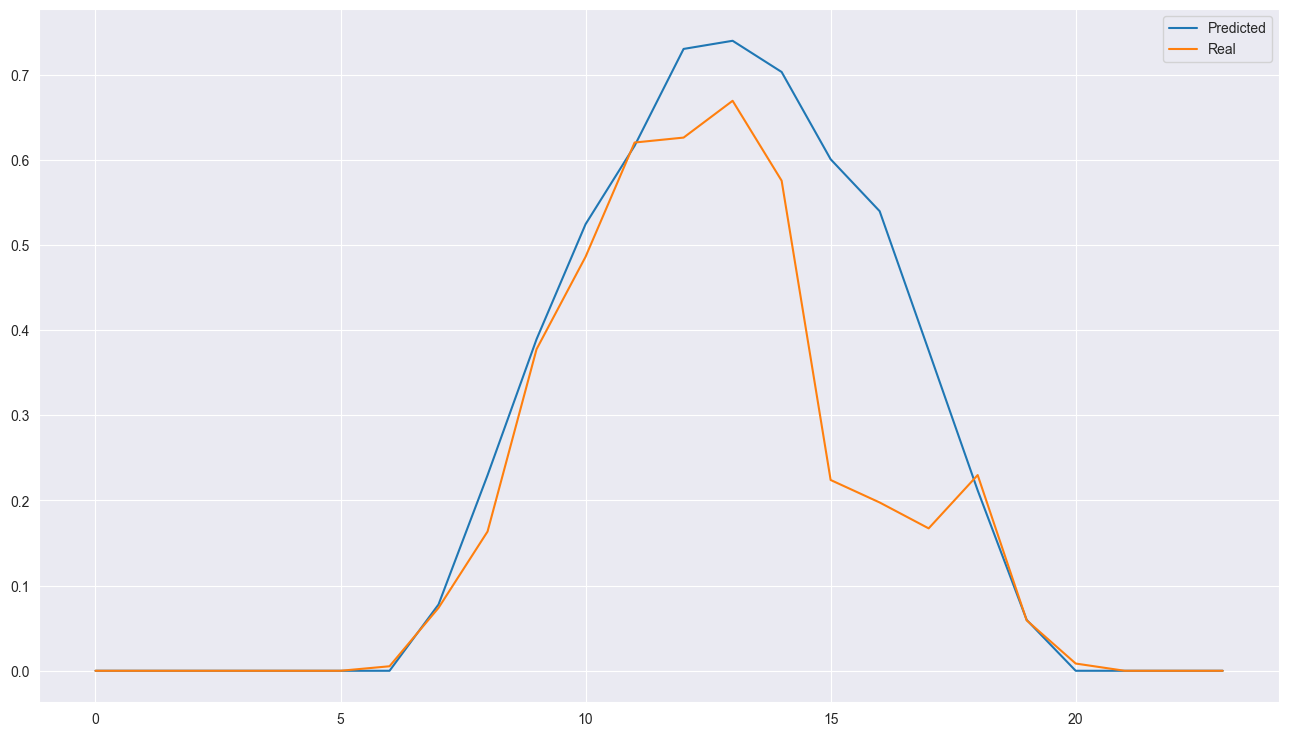

In [92]:
plt.figure(figsize= (16, 9))
plt.plot(y_pred_flat, label = "Predicted")
plt.plot(y_test_flat, label = "Real")
plt.legend()
plt.show()

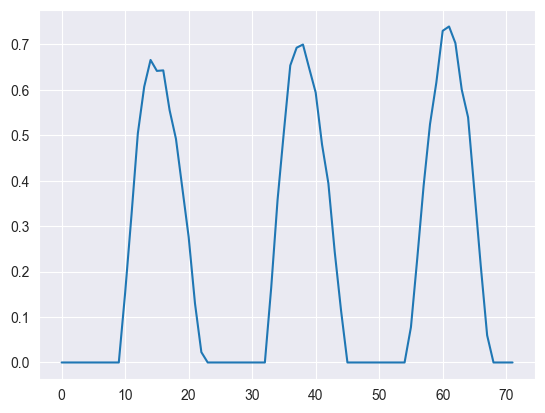

In [49]:
plt.plot(y_pred.flatten()[-72:])

In [28]:
y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df.head(20)

,Predicted,True
0,0.044427,0.0908
1,0.000000,0.0161
2,0.000000,0.0000
3,0.000000,0.0000
4,0.000000,0.0000
5,0.000000,0.0000
6,0.000000,0.0000
7,0.000000,0.0000
8,0.000000,0.0000
9,0.000000,0.0000


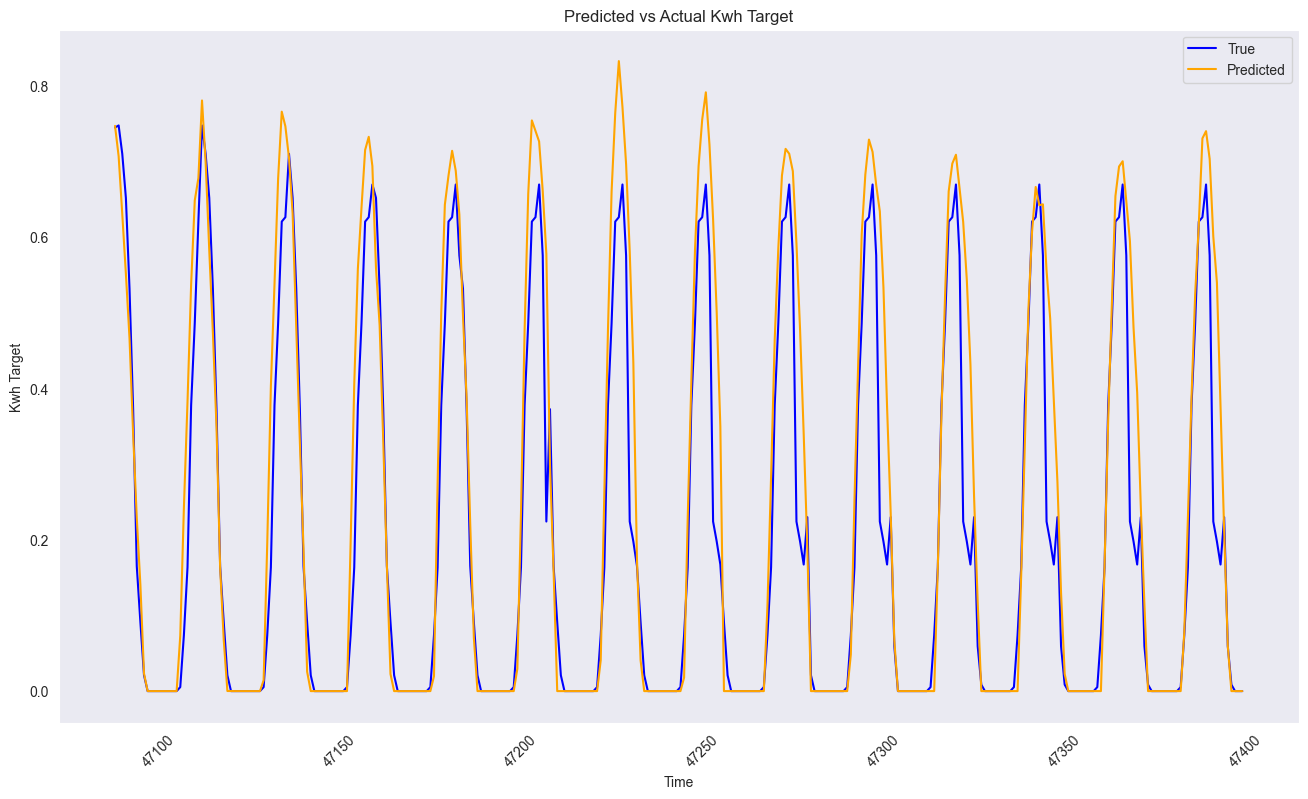

In [30]:
last_312_df = results_df.tail(312)


plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
plt.title('Predicted vs Actual Kwh Target')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [29]:
r2_score(y_pred_flat, y_test_flat)

0.8476013555534204